Adding the necessary libraries

In [7]:
#!/usr/bin/env python3
import pandas as pd
import matplotlib.pyplot as plt

Loading video game sales data from github to a dataframe

In [112]:
url = "https://gist.githubusercontent.com/designernatan/27da044c6dc823f7ac7fe3a01f4513ed/raw/d15b5c7d7a5efb38750b16ec935fc126ec9a6e79/vgsales.csv"

videoGameData_df = pd.read_csv(url)

pd.set_option('display.width', None)
display(videoGameData_df.head(10))

#videoGameData_df.to_csv('videoGameData.csv')      #saving video game data to a csv as backup

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Exploratory Data Analysis

Looking at video games by platform

,Platform,count
0,DS,2163
1,PS2,2161
2,PS3,1329
3,Wii,1325
4,X360,1265
5,PSP,1213
6,PS,1196
7,PC,960
8,XB,824
9,GBA,822


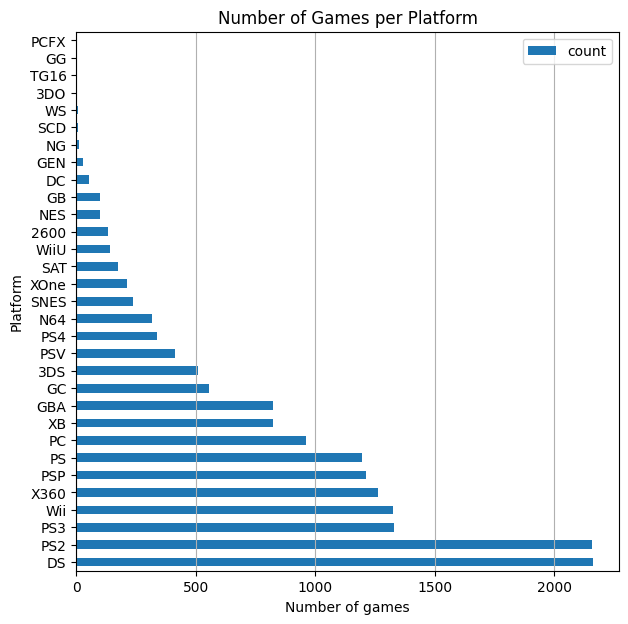

In [42]:
df = videoGameData_df['Platform'].value_counts().reset_index()
#df = df.to_frame()
display(df)
#print(df.columns.tolist())

df.plot(x='Platform', y='count', kind='barh', figsize=[7,7])
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

Looking at Game genre distribution overall

           Genre  count
0         Action   3316
1         Sports   2346
2           Misc   1739
3   Role-Playing   1488
4        Shooter   1310
5      Adventure   1286
6         Racing   1249
7       Platform    886
8     Simulation    867
9       Fighting    848
10      Strategy    681
11        Puzzle    582


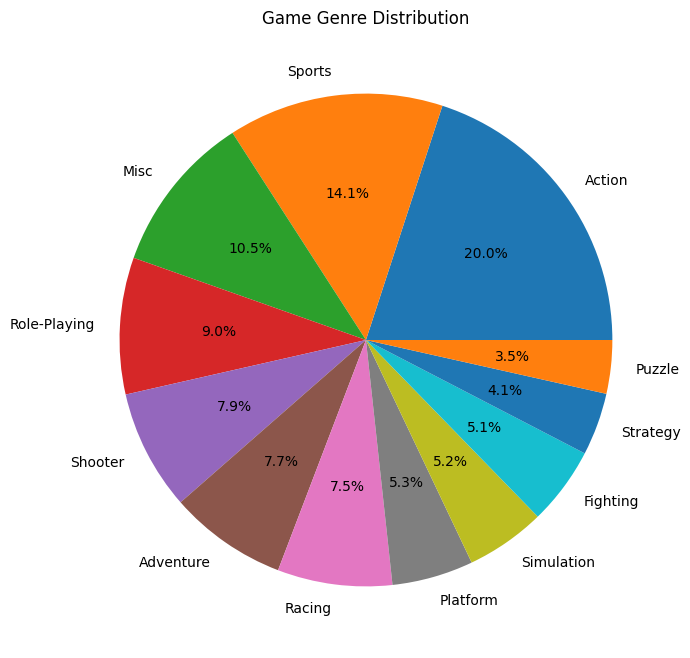

In [58]:
df = videoGameData_df['Genre'].value_counts().reset_index()
print(df)

df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title('Game Genre Distribution')
plt.show()

Looking at the platforms with the most and least games released

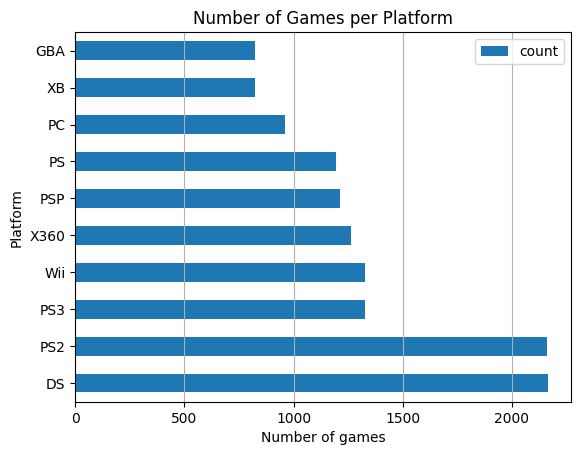

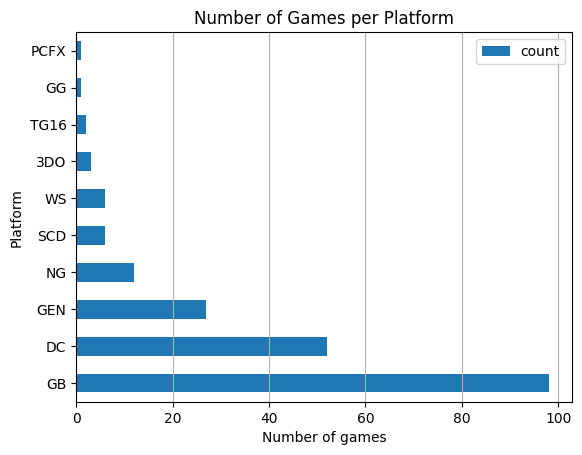

In [ ]:
df = videoGameData_df['Platform'].value_counts().reset_index()

dfMost = df.head(10)
dfMost.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

dfLeast = df.tail(10)
dfLeast.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

Looking at video game genres for top 3 most popular platforms

DS


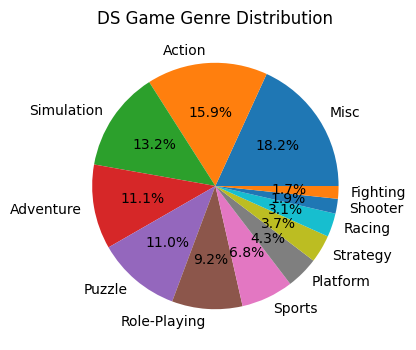

PS2


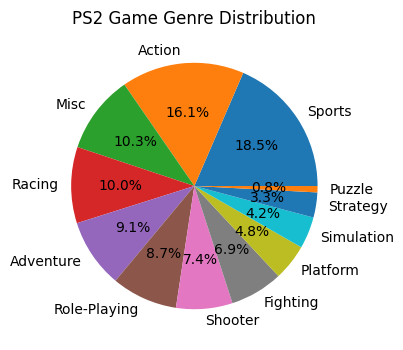

PS3


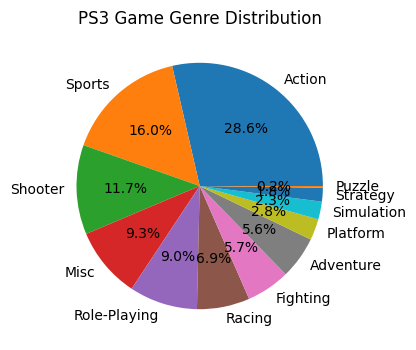

In [109]:
'''#print(dfMost['Platform'][0])
platform1 = dfMost['Platform'][0]   #getting name of platform with most games
print(platform1)

df = videoGameData_df[videoGameData_df['Platform']==platform1]['Genre'].value_counts().reset_index()    #getting count per genre for platform 1
#print(df)
df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title(platform1 + ' Game Genre Distribution')
plt.show()'''

df = videoGameData_df['Platform'].value_counts().reset_index()

counter = 0
while (counter<3): 
    platform = dfMost['Platform'][counter]   #getting name of platform with most games
    print(platform)

    df = videoGameData_df[videoGameData_df['Platform']==platform]['Genre'].value_counts().reset_index()    #getting count per genre for platform 1
    #print(df)
    df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(4,4), legend=False)
    plt.ylabel('')
    plt.title(platform + ' Game Genre Distribution')
    plt.show()

    counter = counter + 1

Sales Trends per Year

Text(0, 0.5, 'Number of Games Sold')

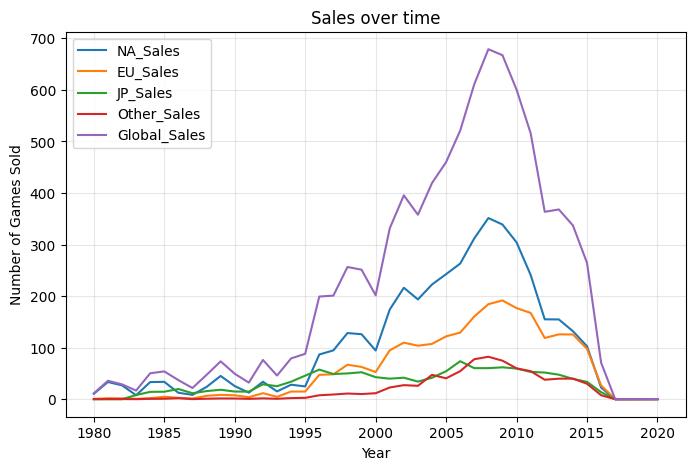

In [106]:
#df = videoGameData_df
'''df = videoGameData_df.groupby('Year')['NA_Sales'].sum().reset_index()
print(df.head(10))'''

df = videoGameData_df.groupby('Year').sum().reset_index()
#print(df.head(10))
#print(df.dtypes)

#fig, ax = plt.subplots(figsize=(8, 5))

fig, ax = plt.subplots(figsize=(8, 5))

#ax.plot(df['Platform'], df['NA_Sales'])
ax.plot(df['Year'], df['NA_Sales'], label='NA_Sales')
ax.plot(df['Year'], df['EU_Sales'], label='EU_Sales')
ax.plot(df['Year'], df['JP_Sales'], label='JP_Sales')
ax.plot(df['Year'], df['Other_Sales'], label='Other_Sales')
ax.plot(df['Year'], df['Global_Sales'], label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales over time')
ax.grid(alpha = 0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games Sold')